# DRank Keyword Extraction (Indianexpress Dataset)
Graph-based DRank implementation for the same dataset used in HRank.
This notebook ranks candidate keywords using a token co-occurrence graph and PageRank-style scoring.

In [1]:
import re
import gzip
import zlib
import urllib.request
from collections import Counter, defaultdict

from bs4 import BeautifulSoup, Comment
import nltk
from nltk.corpus import stopwords, wordnet
from nltk import wordpunct_tokenize
from nltk.stem import SnowballStemmer
import spacy
from compound_split.doc_split import get_best_split

for pkg in ["stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.data.find(f"corpora/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)

try:
    nlp_fi = spacy.load("fi_core_news_sm")
except Exception:
    import os
    os.system("python3 -m spacy download fi_core_news_sm")
    nlp_fi = spacy.load("fi_core_news_sm")

COMMON_NOISE_WORDS = set(
    """
january debt est dec big than who use jun jan feb mar apr may jul agust dec oct nov sep dec
product continue one two three four five please thanks find helpful week job experience women girl
apology read show eve knowledge benefit appointment street way staff salon discount gift cost thing
world close party love letters rewards offers special close page week dollars voucher gifts vouchers
welcome therefore march nights need name pleasure show sisters thank menu today always time needs
welcome march february april may june jully aguast september october november december day year
month minute second secodns
""".split()
)

SPECIAL_CHARS_RE = re.compile(
    r"[ \~\!\@\#\\\$\%\^\&\*\(\)\_\+\=\\\|\{\}\[\]\:\;\'\"\<\>\,\/\.\-]"
)

stemmer = SnowballStemmer("finnish")
POS_MAP = {"J": wordnet.ADJ, "V": wordnet.VERB, "N": wordnet.NOUN, "R": wordnet.ADV}

def finnish_lemmatize(word: str) -> str:
    doc = nlp_fi(word)
    return doc[0].lemma_ if doc else word

def _split_compound_word(word: str) -> list:
    try:
        split_result = get_best_split(word)
        if isinstance(split_result, list):
            return [p.lower() for p in split_result if isinstance(p, str) and p]
        if (
            isinstance(split_result, tuple)
            and len(split_result) == 2
            and isinstance(split_result[1], (list, tuple))
        ):
            return [p.lower() for p in split_result[1] if isinstance(p, str) and p]
    except Exception:
        pass
    return []

def _expand_compound_tokens(tokens: list) -> list:
    expanded = []
    for token in tokens:
        if not token:
            continue
        expanded.append(token)
        for part in _split_compound_word(token):
            if part != token and len(part) > 1:  # Filter out single-character parts
                expanded.append(part)
    return expanded

def _is_visible_text(element) -> bool:
    if element.parent.name in ["html", "style", "script", "head", "[document]", "img"]:
        return False
    if isinstance(element, Comment):
        return False
    return True

def _extract_visible_text_from_html(html: bytes) -> str:
    soup = BeautifulSoup(html, "lxml")
    texts = soup.find_all(string=True)
    visible_texts = filter(_is_visible_text, texts)
    return " ".join(t.strip() for t in visible_texts if t and t.strip())

def _normalize_whitespace(text: str) -> str:
    lines = (line.strip() for line in text.splitlines())
    chunks = (phrase.strip() for line in lines for phrase in line.split(" "))
    return "\n".join(chunk for chunk in chunks if chunk)

def _decode_response_body(html: bytes, encoding: str) -> bytes:
    enc = (encoding or "").lower()
    if enc == "gzip":
        try:
            return gzip.decompress(html)
        except Exception:
            return html
    if enc == "deflate":
        try:
            return zlib.decompress(html)
        except Exception:
            try:
                return zlib.decompress(html, -zlib.MAX_WBITS)
            except Exception:
                return html
    return html

def _fetch_page(u: str):
    req = urllib.request.Request(
        u,
        headers={
            "User-Agent": "Mozilla/5.0",
            "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
            "Accept-Language": "fi-FI,fi;q=0.9",
            "Connection": "keep-alive",
        },
    )
    with urllib.request.urlopen(req, timeout=20) as resp:
        html = resp.read()
        html = _decode_response_body(html, resp.headers.get("Content-Encoding", ""))
        clean_text = _normalize_whitespace(_extract_visible_text_from_html(html))
        return clean_text

def _calculate_language_scores(text: str) -> dict:
    ratios = {}
    tokens = wordpunct_tokenize(text)
    words = [w.lower() for w in tokens]
    words_set = set(words)
    for lang in stopwords.fileids():
        try:
            stop_set = set(stopwords.words(lang))
            ratios[lang] = len(words_set.intersection(stop_set))
        except Exception:
            continue
    return ratios

def _detect_language_and_stopwords(text: str):
    ratios = _calculate_language_scores(text)
    preferred = [
        "finnish", "swedish", "danish", "norwegian", "english",
        "german", "dutch", "french", "spanish", "italian", "portuguese"
    ]
    available = [lang for lang in preferred if lang in stopwords.fileids()]
    if not available:
        return "finnish", set(stopwords.words("finnish"))
    detected_lang = max(available, key=lambda lang: ratios.get(lang, 0))
    try:
        sw = set(stopwords.words(detected_lang))
    except Exception:
        detected_lang, sw = "finnish", set(stopwords.words("finnish"))
    return detected_lang, sw

def _stem_and_lemmatize_tokens(tokens):
    out = []
    for word in tokens:
        lemma = finnish_lemmatize(word)
        stem = stemmer.stem(lemma)
        out.append(stem)
    return out

def _filter_candidate_pos(tokens):
    if not tokens:
        return []
    text = " ".join(tokens)
    doc = nlp_fi(text)
    return [tok.text.lower() for tok in doc if tok.pos_ in {"NOUN", "PROPN", "ADJ"}]

def normalize_keywords(keywords):
    cleaned = [SPECIAL_CHARS_RE.sub("", w.lower().strip()) for w in keywords if w]
    cleaned = [w for w in cleaned if w and len(w) > 1 and not w.isdigit()]
    cleaned = _expand_compound_tokens(cleaned)
    cleaned = _filter_candidate_pos(cleaned)  # Apply POS filtering for consistency
    cleaned = _stem_and_lemmatize_tokens(cleaned)
    cleaned = [w for w in cleaned if len(w) > 1]  # Filter out single-character results after stemming
    return cleaned

def _clean_text_to_words(text: str, stopword_list: set) -> list:
    tokens = [SPECIAL_CHARS_RE.sub("", w.lower().strip()) for w in wordpunct_tokenize(text)]
    tokens = [
        t for t in tokens
        if t and len(t) > 1 and not t.isdigit()
        and t not in stopword_list and t not in COMMON_NOISE_WORDS
    ]
    tokens = _expand_compound_tokens(tokens)
    tokens = _filter_candidate_pos(tokens)
    return _stem_and_lemmatize_tokens(tokens)

def Get_Prc_Rcl_Fscr_input_GT_and_Keywords_List(ground_truth, keywords):
    gt_set = set(ground_truth)
    kw_set = set(keywords)
    matches = gt_set.intersection(kw_set)
    gt_count, kw_count, match_count = len(gt_set), len(kw_set), len(matches)
    if gt_count == 0 or kw_count == 0:
        return (0, 0, 0)
    precision = match_count / kw_count
    recall = match_count / gt_count
    f_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return (precision, recall, f_score)

def read_url(url):
    with urllib.request.urlopen(url) as f:
        return f.read().decode("utf-8-sig", errors="ignore").strip()

def load_herald_case(index):
    base = "https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/ruoka"
    url_text = read_url(f"{base}/{index}/URL.txt")
    gt_text = read_url(f"{base}/{index}/GT.txt")
    return url_text, gt_text.split(), base

In [2]:
def _build_cooccurrence_graph(tokens, window_size=4):
    graph = defaultdict(lambda: defaultdict(float))
    n = len(tokens)
    for i in range(n):
        wi = tokens[i]
        end = min(i + window_size, n)
        for j in range(i + 1, end):
            wj = tokens[j]
            if wi == wj:
                continue
            dist = j - i
            weight = 1.0 / dist
            graph[wi][wj] += weight
            graph[wj][wi] += weight
    return graph


def _run_pagerank(graph, damping=0.85, max_iter=100, tol=1e-6):
    nodes = list(graph.keys())
    if not nodes:
        return {}

    n = len(nodes)
    score = {node: 1.0 / n for node in nodes}
    out_weight_sum = {node: sum(graph[node].values()) for node in nodes}

    for _ in range(max_iter):
        new_score = {node: (1.0 - damping) / n for node in nodes}

        dangling_mass = sum(
            score[node] for node in nodes if out_weight_sum[node] == 0.0
        )
        dangling_share = damping * dangling_mass / n
        for node in nodes:
            new_score[node] += dangling_share

        for src in nodes:
            if out_weight_sum[src] == 0.0:
                continue
            for dst, w in graph[src].items():
                new_score[dst] += damping * score[src] * (w / out_weight_sum[src])

        diff = sum(abs(new_score[node] - score[node]) for node in nodes)
        score = new_score
        if diff < tol:
            break

    return score


def get_top_keywords_drank(
    url: str, k: int = 10, window_size: int = 4, return_details: bool = False
):
    clean_text = _fetch_page(url)
    _, sw = _detect_language_and_stopwords(clean_text)
    tokens = _clean_text_to_words(clean_text, sw)
    if not tokens:
        return []

    graph = _build_cooccurrence_graph(tokens, window_size=window_size)
    drank_scores = _run_pagerank(graph)

    tf = Counter(tokens)
    final_scores = {}
    for w, c in tf.items():
        if len(w) > 1:  # Filter out single-character keywords
            final_scores[w] = c * drank_scores.get(w, 0.0)

    top = sorted(final_scores.items(), key=lambda kv: kv[1], reverse=True)[:k]
    if return_details:
        return [(w, tf[w], s) for w, s in top]
    return [w for w, _ in top]

In [3]:
def run_single_case_drank(index=0, k=10, window_size=4):
    url, gt_keywords, base = load_herald_case(str(index))
    gt_keywords_norm = normalize_keywords(gt_keywords)
    found_keywords = get_top_keywords_drank(base + f"/{index}", k=k, window_size=window_size)
    p, r, f = Get_Prc_Rcl_Fscr_input_GT_and_Keywords_List(
        gt_keywords_norm, found_keywords
    )
    return {
        "index": index,
        "url": url,
        "ground_truth": gt_keywords,
        "ground_truth_normalized": gt_keywords_norm,
        "predicted": found_keywords,
        "precision": round(p, 4),
        "recall": round(r, 4),
        "f_score": round(f, 4),
    }


def run_evaluation_drank(total_webpages=10, k=10, window_size=4):
    p_sum, r_sum, f_sum = 0.0, 0.0, 0.0
    valid = 0
    for i in range(total_webpages):
        try:
            url, gt_keywords, base = load_herald_case(str(i))
            gt_keywords_norm = normalize_keywords(gt_keywords)
            found_keywords = get_top_keywords_drank(base + f"/{i}", k=k, window_size=window_size)
            p, r, f = Get_Prc_Rcl_Fscr_input_GT_and_Keywords_List(
                gt_keywords_norm, found_keywords
            )
            p_sum += p
            r_sum += r
            f_sum += f
            valid += 1
        except Exception:
            continue

    if valid == 0:
        return {
            "average_precision": 0,
            "average_recall": 0,
            "average_f_score": 0,
            "total_webpages": total_webpages,
            "evaluated_webpages": 0,
        }

    return {
        "average_precision": round(p_sum / valid, 4),
        "average_recall": round(r_sum / valid, 4),
        "average_f_score": round(f_sum / valid, 4),
        "total_webpages": total_webpages,
        "evaluated_webpages": valid,
    }

In [4]:
case = run_single_case_drank(index=0, k=10, window_size=4)
print("URL:", case["url"])
print("GT:", case["ground_truth"])
print("GT Normalized:", case["ground_truth_normalized"])
print("Predicted:", case["predicted"])
print("Precision:", case["precision"])
print("Recall:", case["recall"])
print("F-score:", case["f_score"])

URL: http://ruoka.fi/blogit/mukana-maku/afrikan-lampoa-kana-paprika-tagine
GT: ['tagine', 'afrika', 'paprika', 'marokko', 'tajine', 'kana', 'pataruoat', 'kikherneet', 'berber', 'mukana', 'maku']
GT Normalized: ['tag', 'afrik', 'paprik', 'maroko', 'taj', 'ka', 'pataruoa', 'berber', 'ber', 'maku']
Predicted: ['maku', 'ruoka', 'tl', 'pai', 'pata', 'hyvä', 'ber', 'berber', 'tag', 'sta']
Precision: 0.4
Recall: 0.4
F-score: 0.4


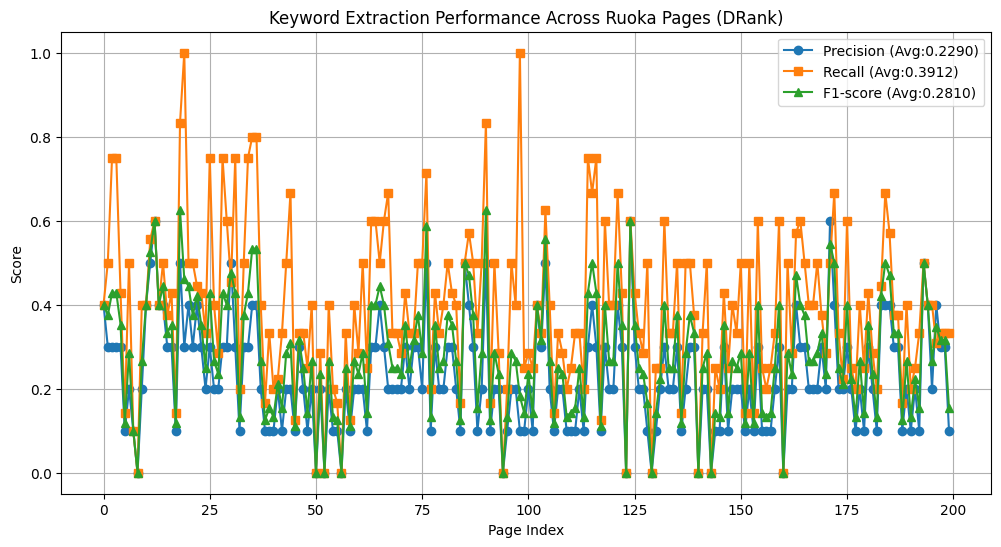

In [5]:
# Visualize and compare performance for DRank
import matplotlib.pyplot as plt
import os
import pandas as pd

results = []
for i in range(200):
    case = run_single_case_drank(index=i, k=10, window_size=4)
    results.append(case)
dataset_precisions = [r['precision'] for r in results]
dataset_recalls = [r['recall'] for r in results]
dataset_f1s = [r['f_score'] for r in results]

plt.figure(figsize=(12, 6))
plt.plot(dataset_precisions, label='Precision (Avg:{0:.4f})'.format(sum(dataset_precisions)/len(dataset_precisions)), marker='o')
plt.plot(dataset_recalls, label='Recall (Avg:{0:.4f})'.format(sum(dataset_recalls)/len(dataset_recalls)), marker='s')
plt.plot(dataset_f1s, label='F1-score (Avg:{0:.4f})'.format(sum(dataset_f1s)/len(dataset_f1s)), marker='^')
plt.xlabel('Page Index')
plt.ylabel('Score')
plt.title('Keyword Extraction Performance Across Ruoka Pages (DRank)')
plt.legend()
plt.grid(True)

# Export graph as image
results_dir = '../Results'
os.makedirs(results_dir, exist_ok=True)
image_path = os.path.join(results_dir, 'DRank_ruoka.png')
plt.savefig(image_path)
plt.show()

# Update results.csv
csv_path = os.path.join(results_dir, 'results.csv')
method = 'DRank_ruoka'
avg_precision = round(sum(dataset_precisions)/len(dataset_precisions), 4)
avg_recall = round(sum(dataset_recalls)/len(dataset_recalls), 4)
avg_f1 = round(sum(dataset_f1s)/len(dataset_f1s), 4)

row = {'DataSet': method, 'Precision': avg_precision, 'Recall': avg_recall, 'F1-score': avg_f1, 'Evaluated Pages': len(results)}

if os.path.exists(csv_path) and os.path.getsize(csv_path) > 0:
    df = pd.read_csv(csv_path)
    df = df[df['DataSet'] != method]
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
else:
    df = pd.DataFrame([row])
df.to_csv(csv_path, index=False)